In [26]:
%load_ext autoreload
%autoreload 2
import sys
from freq2clean import Freq2Clean
import torch

sys.path.append("..")
from src import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
trainings = sorted(Path("trainings").glob("*/"), reverse=True)
cprint(*[f"rand:{training.stem}" for training in trainings], sep='\n')

20251120-1440-mouse_neuronal_populations_deepcad_15
20251120-1434-mouse_neuronal_populations_deepcad_15
20251120-1428-mouse_neuronal_populations_deepcad_15
20251120-1237-mouse_neuronal_populations_deepcad_15
20251118-1221-synthetic_deepcad_150
20251118-1205-synthetic_deepcad_15
20251112-1153-synthetic_deepcad_150
20251112-1054-synthetic_deepcad_150
20251112-1044-synthetic_deepcad_150
20251112-1038-synthetic_deepcad_150
20251112-1034-synthetic_deepcad_150


In [28]:
SELECTED_TRAINING = "20251118-1205-synthetic_deepcad_15"

In [29]:
training_dir = Path("trainings") / SELECTED_TRAINING
cfg = json.load(open(training_dir / "cfg.json"))
ckpts = sorted((training_dir / "pth").glob("*.pt"), key=lambda file: int(file.stem))
cprint(*[f"rand:{ckpt.stem}{ckpt.suffix}" for ckpt in ckpts], sep='\t')

0.pt	19.pt


In [35]:
y = Recording(
    f"dataset/synthetic/deepcad_150.tif",
    max_frames=None,
    norm=True,
)

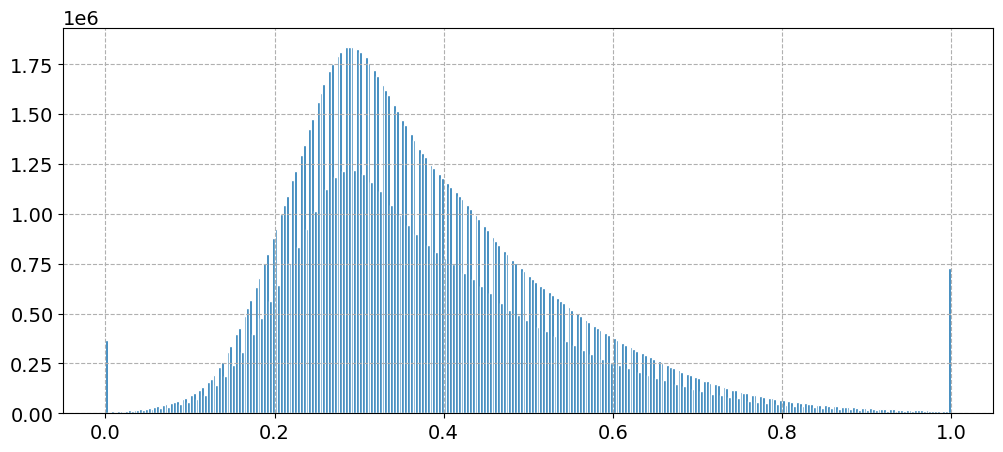

In [36]:
y.hist(step=10, bins=300)

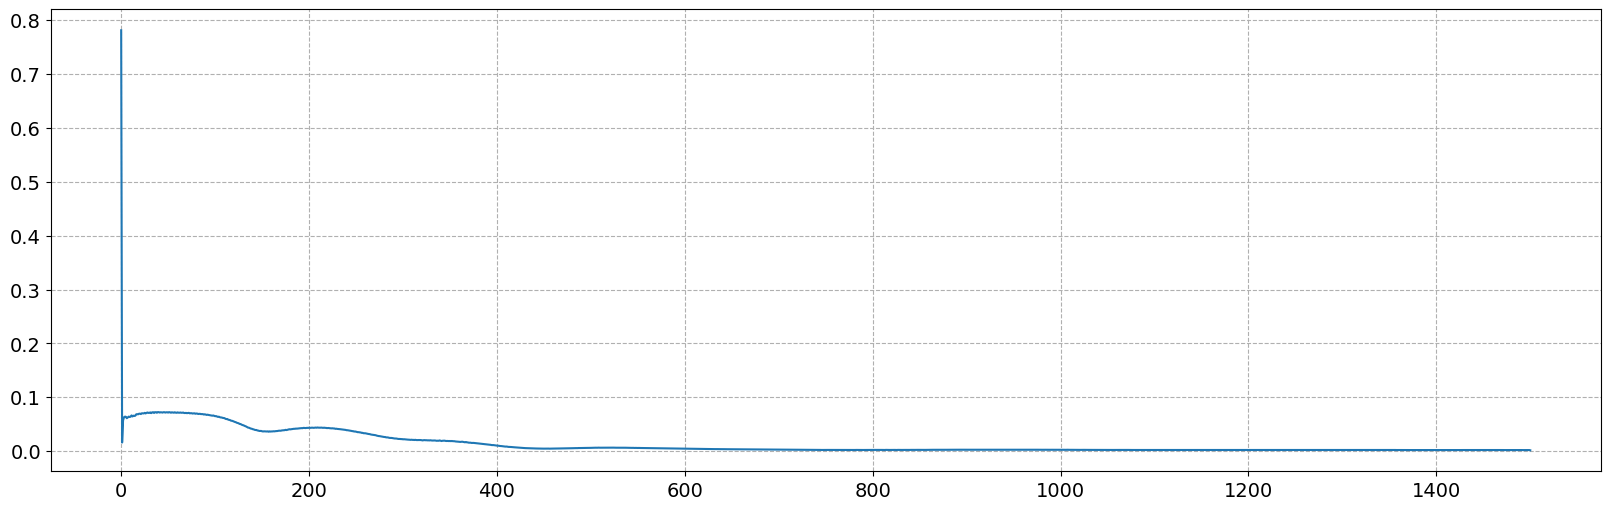

In [11]:
SELECTED_CKPT = 19
model = Freq2Clean(shape=(cfg["patch_t"],), mode=cfg.get("frequency_transform", "dft1d"))
model.load_state_dict(torch.load(training_dir / f"pth/{SELECTED_CKPT}.pt"))

fig, ax = plt.subplots(1,1,figsize=(20, 6))
pd.Series(model.mask.cpu().detach().numpy()).plot(ax=ax)
plt.show()